Zunächst importieren wir uns ein Testbild, das wir im Laufe der Aufgabe verwenden wollen.

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.data import coins
img = coins()

Wie groß ist das Bild? Welchen Elementtyp hat es? Wie viele Pixel behinhaltet das Bild?

In [43]:
print(f"Größe des Bildes:\t{img.shape}")
print(f"Datentyp des Bildes:\t{img.dtype}")
print(f"Gesamtzahl der Pixel:\t{img.size}")

Größe des Bildes:	(303, 384)
Datentyp des Bildes:	uint8
Gesamtzahl der Pixel:	116352


Zeigt das Bild an.

(np.float64(-0.5), np.float64(383.5), np.float64(302.5), np.float64(-0.5))

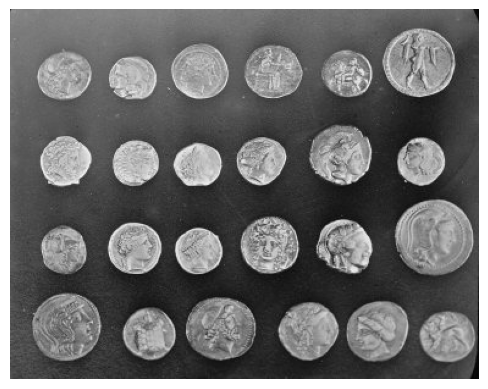

In [44]:
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")

Welchen Wert hat das Pixel in der oberen linken Ecke?

In [45]:
print(img[0, 0])

47


Schreibt eine Funktion, die zählt, wie viele Pixel einen Wert haben, der kleiner ist als der des ersten Pixels.  Nutzt dazu zwei verschachtelte `for`-Schleifen.

In [46]:
def count_small_pixel_value(img: np.ndarray) -> int:
    count = 0
    check_value = img[0, 0]
    for x in range(img.shape[0]):
        for y in range(img.shape[1]):
            if img[x, y] < check_value:
                count += 1
    return count

Wie lässt sich das ohne `for`-Schleifen lösen?

In [53]:
print(np.sum(img < img[0, 0]))

print(np.count_nonzero(img < img[0, 0])) # ist noch schneller als mit np.sum :)

24645
24645


Welche Variante ist schneller? Ruft sie dazu jeweils 100 mal auf und messt die Zeit mit time.time.


In [54]:
import time
start = time.time()
for _ in range(100):
    count = count_small_pixel_value(img)
print(time.time() - start)

start = time.time()
for _ in range(100):
    count = np.sum(img < img[0, 0])
print(time.time() - start)

start = time.time()
for _ in range(100):
    count = np.count_nonzero(img < img[0, 0])
print(time.time() - start)

0.9088649749755859
0.003191232681274414
0.0008130073547363281


Wie kann man in einer Zeile prüfen, wie viele Pixel im Bereich zwischen 100 und 200 liegen?

In [49]:
print(np.sum((100 <= img) & (img <= 200)))

46063
